# This is the file used to perform preliminary analysis on the data

In [1]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split

In [2]:
# Load the master_df
master_df = pd.read_csv("master_df.csv")
master_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5219 entries, 0 to 5218
Data columns (total 18 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  5219 non-null   int64  
 1   IWM_Close   5219 non-null   float64
 2   QQQ_Close   5219 non-null   float64
 3   SPY_Close   5219 non-null   float64
 4   IWM_High    5219 non-null   float64
 5   QQQ_High    5219 non-null   float64
 6   SPY_High    5219 non-null   float64
 7   IWM_Low     5219 non-null   float64
 8   QQQ_Low     5219 non-null   float64
 9   SPY_Low     5219 non-null   float64
 10  IWM_Open    5219 non-null   float64
 11  QQQ_Open    5219 non-null   float64
 12  SPY_Open    5219 non-null   float64
 13  IWM_Volume  5219 non-null   float64
 14  QQQ_Volume  5219 non-null   float64
 15  SPY_Volume  5219 non-null   float64
 16  VIX         5219 non-null   float64
 17  Date        5219 non-null   object 
dtypes: float64(16), int64(1), object(1)
memory usage: 734.1+ KB


In [3]:
# Compute correlation matrix
numeric_df = master_df.select_dtypes(include=['float64', 'int64'])

# Compute correlation matrix
corr_matrix = numeric_df.corr(method='pearson')

print(corr_matrix.round(3))

            Unnamed: 0  IWM_Close  QQQ_Close  SPY_Close  IWM_High  QQQ_High  \
Unnamed: 0       1.000      0.944      0.895      0.915     0.944     0.895   
IWM_Close        0.944      1.000      0.946      0.962     1.000     0.946   
QQQ_Close        0.895      0.946      1.000      0.996     0.946     1.000   
SPY_Close        0.915      0.962      0.996      1.000     0.963     0.995   
IWM_High         0.944      1.000      0.946      0.963     1.000     0.946   
QQQ_High         0.895      0.946      1.000      0.995     0.946     1.000   
SPY_High         0.915      0.962      0.995      1.000     0.962     0.996   
IWM_Low          0.943      1.000      0.945      0.962     1.000     0.945   
QQQ_Low          0.895      0.946      1.000      0.995     0.946     1.000   
SPY_Low          0.914      0.963      0.995      1.000     0.963     0.995   
IWM_Open         0.943      1.000      0.945      0.962     1.000     0.945   
QQQ_Open         0.895      0.946      1.000      0.

In [4]:
# Sort correlation pairs
corr_pairs = corr_matrix.unstack().sort_values(ascending=False)
# Drop self-correlations (=1.0)
corr_pairs = corr_pairs[corr_pairs < 1.0]
print(corr_pairs.head(20))

SPY_High   SPY_Open     0.999942
SPY_Open   SPY_High     0.999942
QQQ_Open   QQQ_High     0.999940
QQQ_High   QQQ_Open     0.999940
QQQ_Low    QQQ_Close    0.999938
QQQ_Close  QQQ_Low      0.999938
SPY_Low    SPY_Open     0.999936
SPY_Open   SPY_Low      0.999936
SPY_Close  SPY_Low      0.999935
SPY_Low    SPY_Close    0.999935
SPY_Close  SPY_High     0.999934
SPY_High   SPY_Close    0.999934
QQQ_Open   QQQ_Low      0.999932
QQQ_Low    QQQ_Open     0.999932
QQQ_Close  QQQ_High     0.999932
QQQ_High   QQQ_Close    0.999932
QQQ_Low    QQQ_High     0.999901
QQQ_High   QQQ_Low      0.999901
SPY_Low    SPY_High     0.999890
SPY_High   SPY_Low      0.999890
dtype: float64


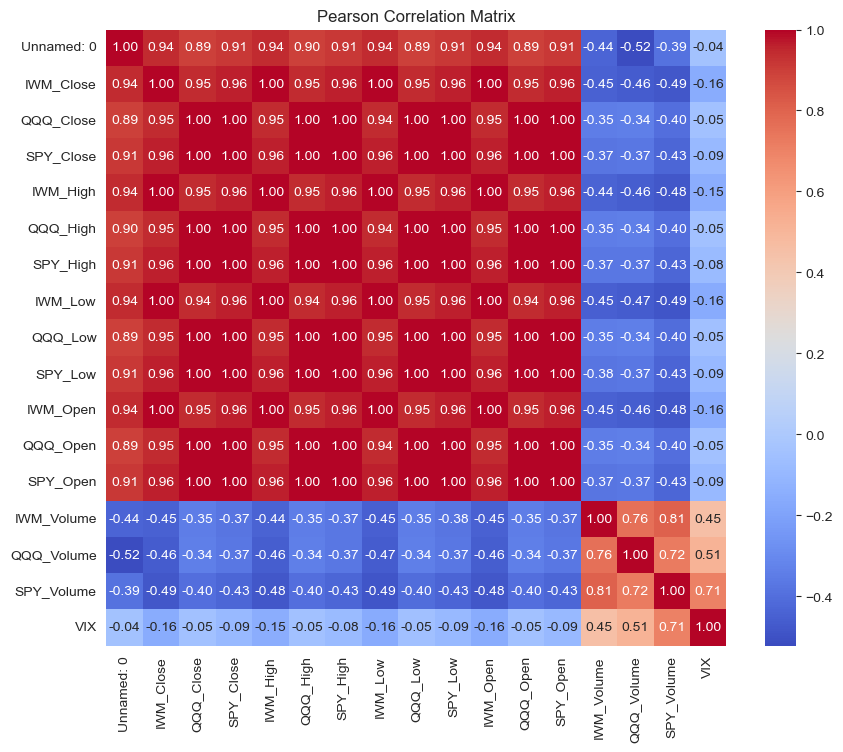

In [5]:
# Visualize correlation matrix
plt.figure(figsize=(10, 8))

# Set the color map to cool-warm
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Pearson Correlation Matrix")

# Save the heatmap
# plt.savefig("pearson_correlation_matrix_heatmap.png")
plt.show()

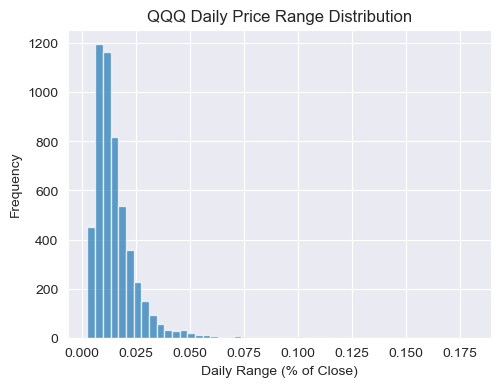

In [6]:
# Compute Range and Range_Pct using string column names
master_df["QQQ_Range"] = master_df["QQQ_High"] - master_df["QQQ_Low"]
master_df["QQQ_Range_Pct"] = master_df["QQQ_Range"] / master_df["QQQ_Close"]

# Plot histogram of the QQQ daily range as a percentage of Close
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(master_df["QQQ_Range_Pct"], bins=50, alpha=0.7)
plt.xlabel('Daily Range (% of Close)')
plt.ylabel('Frequency')
plt.title('QQQ Daily Price Range Distribution')
plt.show()

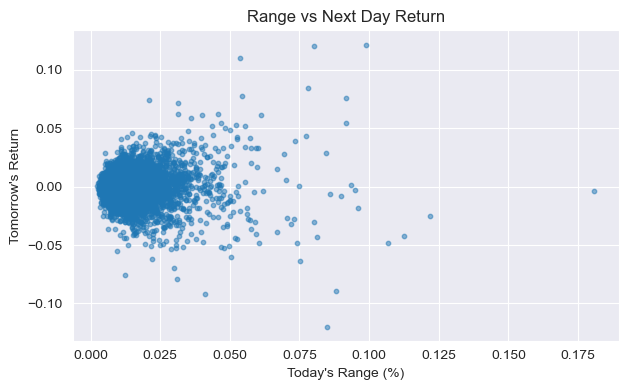

In [7]:
# Compute tomorrow's return using string column name
master_df["Tomorrow_Return"] = master_df["QQQ_Close"].pct_change().shift(-1)

# Scatter plot: today's range vs tomorrow's return
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 2)
plt.scatter(
    master_df["QQQ_Range_Pct"],
    master_df["Tomorrow_Return"],
    alpha=0.5, s=10
)
plt.xlabel("Today's Range (%)")
plt.ylabel("Tomorrow's Return")
plt.title("Range vs Next Day Return")
plt.tight_layout()
plt.show()

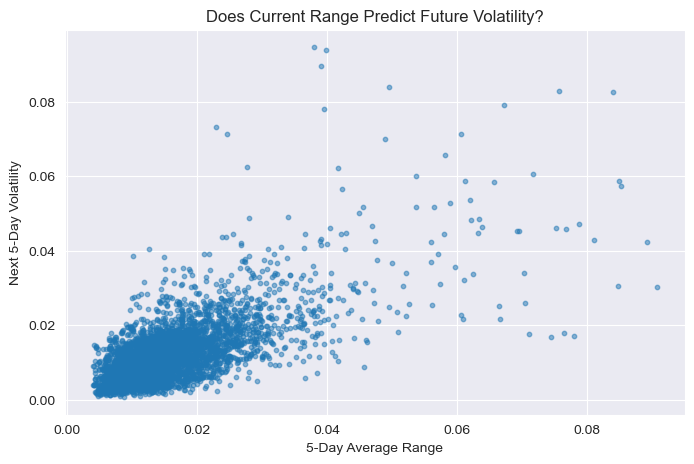

In [8]:
# Analyze if high ranges predict future volatility

# Compute 5-day moving average of QQQ's daily range percentage
master_df["Range_MA"] = master_df["QQQ_Range_Pct"].rolling(window=5).mean()

# Compute 5-day future volatility (std of returns)
master_df["Future_Volatility"] = (
    master_df["QQQ_Close"]
    .pct_change()
    .rolling(window=5)
    .std()
    .shift(-5)
)

# Scatter plot: average range vs future volatility
plt.figure(figsize=(8, 5))
plt.scatter(master_df["Range_MA"], master_df["Future_Volatility"], alpha=0.5, s=10)
plt.xlabel("5-Day Average Range")
plt.ylabel("Next 5-Day Volatility")
plt.title("Does Current Range Predict Future Volatility?")
plt.show()

In [9]:
# TODO: get Reagan's regression plot back